<a href="https://colab.research.google.com/github/bpickett14/AdvancedStatisticalMethods/blob/main/WrittenReportChapter5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Brenna Bunderson - Written Report Ch 5

In [ ]:
install.packages('Sleuth3')
library('Sleuth3')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
head(ex0523)

,Oxygen,Bone
,<dbl>,<fct>
1,11.10,Bone1
2,11.22,Bone1
3,11.29,Bone1
4,11.49,Bone1
5,11.32,Bone2
6,11.40,Bone2


#Introduction: Describe the Data and Present the Question
Scientists have long debated whether Tyrannosaurus rex was warm-blooded or not. One way to investigate this is by analyzing the oxygen isotopic composition of bone phosphate, which is related to the body temperature at which bone forms. Measurements from 12 different bones of a single T. rex skeleton were provided.

If the animal maintained a constant internal temperature, the mean isotopic values across bones should be similar, with only small differences. Larger differences would suggest temperature variation throughout the body. The question addressed in this report is whether the mean isotopic compositions differ among the bones, which would provide evidence about whether T. rex had a constant body temperature.

#Graphical Analysis

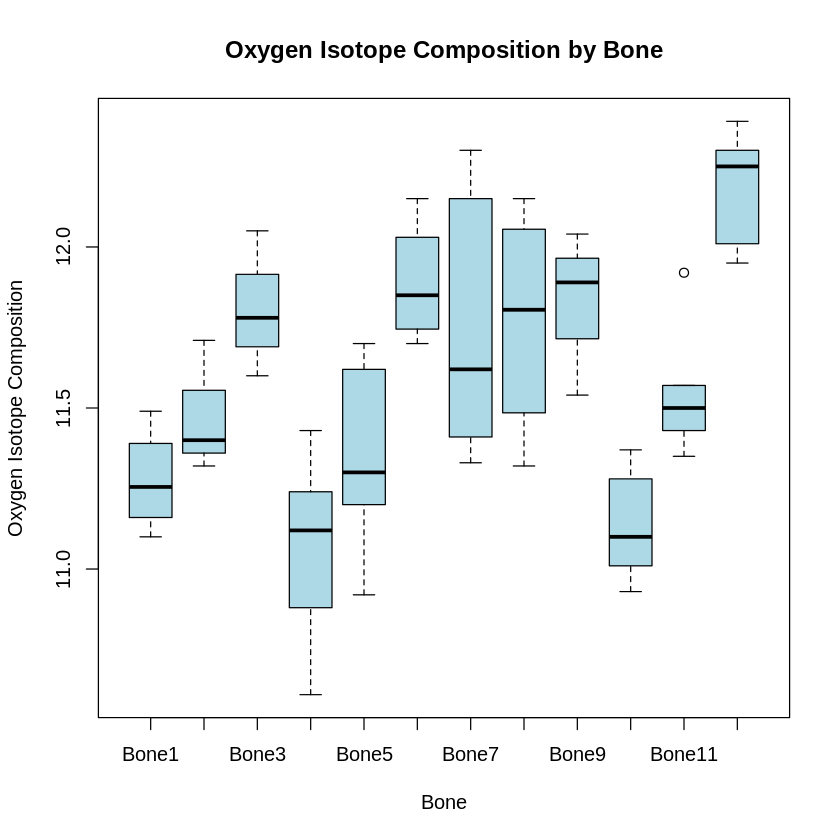

In [ ]:
# Make sure Bone is a factor
ex0523$Bone <- as.factor(ex0523$Bone)

# Reorder levels numerically
ex0523$Bone <- factor(ex0523$Bone, levels = paste0("Bone", 1:12))

boxplot(Oxygen ~ Bone,
        data = ex0523,
        main = "Oxygen Isotope Composition by Bone",
        xlab = "Bone",
        ylab = "Oxygen Isotope Composition",
        col = "lightblue")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



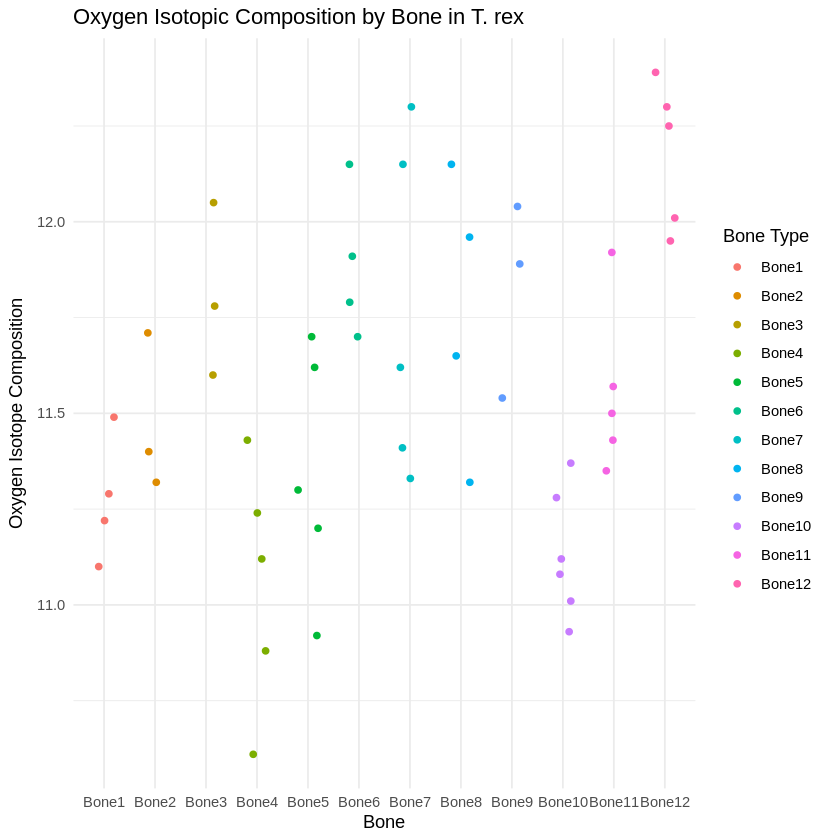

In [ ]:
install.packages("ggplot2")
library(ggplot2)

# Create a scatterplot with bone as color hue
ggplot(ex0523, aes(x = Bone, y = Oxygen, color = Bone)) +
  geom_jitter(width = 0.2, height = 0) + # Use geom_jitter to spread overlapping points
  labs(
    title = "Oxygen Isotopic Composition by Bone in T. rex",
    x = "Bone",
    y = "Oxygen Isotope Composition",
    color = "Bone Type"
  ) +
  theme_minimal()


#Assumptions
This is an ANOVA problem.

ANOVA has three assumptions that we have to verify: Independence, Normality, and Equal Variances.

###Independence
ANOVA requires independence between groups and within groups. This is questionable because all measurements come from bones of a single Tyrannosaurus Rex skeleton. Observations from the same individual may be correlated, meaning they are not fully independent. Because all measurements come from bones of a single individual, the independence assumption is violated, and results should be interpreted with caution.

###Normality

In [ ]:
shapiro.test(aov(Oxygen ~ Bone, data = ex0523)$residual)


	Shapiro-Wilk normality test

data:  aov(Oxygen ~ Bone, data = ex0523)$residual
W = 0.97397, p-value = 0.3091


With a Shapiro-Wilk p-value of 0.3091, we fail to reject the null hypothesis of normally distributed residuals, suggesting that the normality assumption is reasonable.

###Equal Variances

In [ ]:
install.packages('lawstat')
library(lawstat)

levene.test(ex0523$Oxygen, ex0523$Bone, location = "mean")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




	Classical Levene's test based on the absolute deviations from the mean
	( none not applied because the location is not set to median )

data:  ex0523$Oxygen
Test Statistic = 1.8122, p-value = 0.08421


With a Levene’s test p-value of 0.5421, we fail to reject the null hypothesis of equal variances, suggesting the assumption of homogeneity of variance is reasonable.

#Statistical Conclusion
here you will discuss the p-values/confidence intervals and conclusions of that statistical analysis and the methods you used (be sure to address the strength of your conclusions)

In [ ]:
summary(aov(Oxygen ~ Bone, data = ex0523))

            Df Sum Sq Mean Sq F value   Pr(>F)    
Bone        11  6.067  0.5516   7.427 9.73e-07 ***
Residuals   40  2.971  0.0743                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

The ANOVA F-test produced a very small p-value (extremely close to 0), providing strong, convincing evidence to reject the null hypothesis that all bone means are equal. This indicates that at least one bone’s mean oxygen isotopic composition differs from the others. Now let's figure out which one(s)!

###Post-Hoc Test

In [ ]:
aov_model <- aov(Oxygen ~ Bone, data = ex0523)
tukey <- TukeyHSD(aov_model)

In [ ]:
tukey

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Oxygen ~ Bone, data = ex0523)

$Bone
                     diff         lwr         upr     p adj
Bone2-Bone1    0.20166667 -0.52009494  0.92342827 0.9975988
Bone3-Bone1    0.53500000 -0.18676161  1.25676161 0.3292850
Bone4-Bone1   -0.21900000 -0.85293048  0.41493048 0.9861313
Bone5-Bone1    0.07300000 -0.56093048  0.70693048 0.9999996
Bone6-Bone1    0.61250000 -0.05572140  1.28072140 0.0991267
Bone7-Bone1    0.48700000 -0.14693048  1.12093048 0.2806001
Bone8-Bone1    0.49500000 -0.17322140  1.16322140 0.3301738
Bone9-Bone1    0.54833333 -0.17342827  1.27009494 0.2954353
Bone10-Bone1  -0.14333333 -0.75333323  0.46666656 0.9994995
Bone11-Bone1   0.27900000 -0.35493048  0.91293048 0.9241389
Bone12-Bone1   0.90500000  0.27106952  1.53893048 0.0007569
Bone3-Bone2    0.33333333 -0.43826228  1.10492895 0.9325118
Bone4-Bone2   -0.42066667 -1.11080276  0.26946943 0.6165605
Bone5-Bone2   -0.12866667 -0

I'm going to separate out the smaller p-values, so we can more easily see the comparisons.

In [ ]:
# Pull the Bone comparisons from TukeyHSD output
tukey_bone <- as.data.frame(tukey$Bone)

# Filter for p ≤ 0.05
significant <- tukey_bone[tukey_bone$`p adj` <= 0.05, ]

#make it look nice...
significant$`p adj` <- round(significant$`p adj`, 4)

significant

,diff,lwr,upr,p adj
,<dbl>,<dbl>,<dbl>,<dbl>
Bone12-Bone1,0.9050000,0.27106952,1.53893048,0.0008
Bone12-Bone2,0.7033333,0.01319724,1.39346943,0.0424
Bone4-Bone3,-0.7540000,-1.44413610,-0.06386390,0.0219
Bone10-Bone3,-0.6783333,-1.34655474,-0.01011193,0.0439
Bone6-Bone4,0.8315000,0.19756952,1.46543048,0.0026
Bone7-Bone4,0.7060000,0.10832461,1.30367539,0.0094
Bone8-Bone4,0.7140000,0.08006952,1.34793048,0.0160
Bone9-Bone4,0.7673333,0.07719724,1.45746943,0.0183
Bone12-Bone4,1.1240000,0.52632461,1.72167539,0.0000


Post-hoc Tukey HSD tests indicate that Bones 12, 4, and 10 differ from multiple other bones. There is a difference between Bone 12 and Bones 1, 2, 4, 5, 10, and 11; Bone 4 differs from Bones 3, 6, 7, 8, 9, and 12; and Bone 10 differs from Bones 3, 6, 7, 8, 9, and 12.

#Scope of Inference
This study is observational, as bones were not assigned to treatment groups. Therefore, conclusions are limited to correlations among bones from this individual T. Rex. While there is strong evidence of differences in mean oxygen isotopic composition among bones, these findings cannot be generalized beyond this specimen.